# Notebook 06 — Full Study Area Inference (All 19 SAs)

Runs sliding-window inference on **all 19 sampling areas** using the best RGB and MS models.

**Purpose:** Generate prediction rasters for the full study area to support landscape-level agricultural statistics in Objective 4.

**What does NOT change:** All accuracy metrics, confusion matrices and FCover agreement results remain computed on test SAs only.

**What this adds:** Prediction rasters for 13 training + 3 val SAs, enabling full spatial coverage maps and more comprehensive Obj 4 statistics.

**Run order:**
- Cell 0: Configuration
- Cell 1: Load models (skip if already in memory)
- Cell 2: Define inference function
- Cell 3: Run inference — all 19 SAs (skips existing rasters)
- Cell 4: Verify all rasters saved
- Cell 5: Quick visualisation — one SA per split
- Cell 6: Next steps guide

> **Note:** In-sample predictions (train/val SAs) are valid for spatial coverage and descriptive statistics but NOT for accuracy assessment.

## Cell 0. Configuration

In [1]:
# ── Configuration ────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import rasterio
import torch
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

BASE_DIR      = Path(r"E:\THESIS_COLLINS HLORDZIE\02_PROCESSED")
PRED_DIR      = BASE_DIR / "Predictions"
RGB_MODEL_DIR = BASE_DIR / "Models" / "rgb_v3"
MS_MODEL_DIR  = BASE_DIR / "Models" / "ms"

# All 19 SAs
ALL_SAS = [
    "9545448", "9805753",  "9965805",  "10085703", "10125706",
    "10145814","10165835", "10165859", "10185850", "10305790",
    "10445787","10565691", "10595716", "10605304", "10765685",
    "10865406","10865805", "11125706", "11226291",
]

# Split map — for labelling outputs
SPLIT_MAP = {
    "11226291":"Train","9965805":"Train","9805753":"Train",
    "10565691":"Train","10305790":"Train","10865406":"Train",
    "10165835":"Train","10085703":"Train","10185850":"Train",
    "9545448":"Train","10445787":"Train","11125706":"Train",
    "10165859":"Train","10145814":"Val","10595716":"Val",
    "10765685":"Val","10125706":"Test","10605304":"Test",
    "10865805":"Test",
}

TEST_SAS = ["10125706","10605304","10865805"]

CLASS_NAMES  = ["Maize","Maize+Pumpkin","Beans+Maize",
                "Cassava+Maize","Grass","Mixed"]
CLASS_COLORS = ["#FFD700","#FF8C00","#33A02C",
                "#A52A2A","#228B22","#808080"]
CMAP         = ListedColormap(CLASS_COLORS)
NUM_CLASSES  = 6
IGNORE_INDEX = 255
TILE_SIZE    = 512
STRIDE       = 256
USE_MASK     = True   # apply MSAVI2 vegetation mask

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device     : {DEVICE}")
print(f"Total SAs  : {len(ALL_SAS)}")
print(f"  Train    : {sum(1 for s in ALL_SAS if SPLIT_MAP[s]=='Train')}")
print(f"  Val      : {sum(1 for s in ALL_SAS if SPLIT_MAP[s]=='Val')}")
print(f"  Test     : {sum(1 for s in ALL_SAS if SPLIT_MAP[s]=='Test')}")
print(f"USE_MASK   : {USE_MASK}")

Device     : cuda
Total SAs  : 19
  Train    : 13
  Val      : 3
  Test     : 3
USE_MASK   : True


## Cell 1. Load models

Skip if `rgb_model` and `ms_model` are already in memory.

In [2]:
# ── Load best RGB and MS models ──────────────────────────────────────────
# Skip this cell if models are already in memory from Notebook 06.

def load_model(model_dir, n_ch):
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/mit-b0",
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True,
        num_channels=n_ch,
    )
    ckpt = torch.load(
        model_dir / f"best_model_{model_dir.name}.pth",
        map_location=DEVICE
    )
    model.load_state_dict(ckpt)
    model.to(DEVICE).eval()
    mean = np.load(model_dir / "mean.npy")
    std  = np.load(model_dir / "std.npy")
    return model, mean, std

rgb_model, RGB_MEAN, RGB_STD = load_model(RGB_MODEL_DIR, 3)
ms_model,  MS_MEAN,  MS_STD  = load_model(MS_MODEL_DIR,  4)
print("RGB model loaded.")
print("MS  model loaded.")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                              | Status     |                                                                                                 
-------------------------------------------------+------------+-------------------------------------------------------------------------------------------------
classifier.weight                                | UNEXPECTED |                                                                                                 
classifier.bias                                  | UNEXPECTED |                                                                                                 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight    | MISSING    |                                                                                                 
decode_head.classifier.weight                    | MISSING    |                                                                   

RGB model loaded.
MS  model loaded.


## Cell 2. Inference function

Same sliding-window soft-voting as Notebook 06.

In [3]:
# ── SA directory helper ──────────────────────────────────────────────────
def get_sa_dir(sa_id):
    for d in BASE_DIR.iterdir():
        if d.is_dir() and d.name.endswith(sa_id):
            return d
    return None

# ── Sliding-window inference ──────────────────────────────────────────────
def run_inference(sa_id, modality):
    """
    Runs sliding-window soft-voting inference on one SA.
    Returns: (pred_array, rasterio_profile)
    """
    sa_dir = get_sa_dir(sa_id)
    if sa_dir is None:
        raise FileNotFoundError(f"SA directory not found for {sa_id}")

    if modality == "rgb":
        img_path  = sa_dir / f"{sa_id}_stack_RGB.tif"
        model     = rgb_model
        mean, std = RGB_MEAN, RGB_STD
        n_ch      = 3
    else:
        img_path  = sa_dir / f"{sa_id}_stack_MS4.tif"
        model     = ms_model
        mean, std = MS_MEAN, MS_STD
        n_ch      = 4

    mask_path = sa_dir / f"{sa_id}_cropland_mask_msavi2_015.tif"

    with rasterio.open(img_path) as src:
        img     = src.read().astype(np.float32)
        profile = src.profile.copy()
        H, W    = src.height, src.width

    # Normalise per channel
    for c in range(n_ch):
        img[c] = (img[c] - mean[c]) / (std[c] + 1e-6)

    # Accumulate soft-voted logits
    logit_sum = np.zeros((NUM_CLASSES, H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    with torch.no_grad():
        for y in range(0, H - TILE_SIZE + 1, STRIDE):
            for x in range(0, W - TILE_SIZE + 1, STRIDE):
                tile = img[:n_ch, y:y+TILE_SIZE, x:x+TILE_SIZE]
                t    = torch.tensor(tile).unsqueeze(0).to(DEVICE)
                out  = model(pixel_values=t)
                lu   = F.interpolate(out.logits,
                                     size=(TILE_SIZE, TILE_SIZE),
                                     mode="bilinear",
                                     align_corners=False)
                logit_sum[:, y:y+TILE_SIZE, x:x+TILE_SIZE] +=                     lu.squeeze(0).cpu().numpy()
                count_map[y:y+TILE_SIZE, x:x+TILE_SIZE] += 1

    count_map = np.where(count_map == 0, 1, count_map)
    pred = (logit_sum / count_map).argmax(axis=0).astype(np.uint8)

    # Apply MSAVI2 vegetation mask
    if USE_MASK and mask_path.exists():
        with rasterio.open(mask_path) as msrc:
            veg_mask = msrc.read(1)
        pred[veg_mask == 0] = IGNORE_INDEX

    return pred, profile

print("Inference function defined.")

Inference function defined.


## Cell 3. Run inference — all 19 SAs

Automatically skips SAs that already have saved prediction rasters.
Test SAs (already processed in Notebook 06) will be skipped.

> Estimated time: 2–5 minutes per SA depending on GPU. Full run ≈ 30–90 minutes for 16 new SAs.

In [4]:
# ── Run inference on all 19 SAs ──────────────────────────────────────────
# Skips SAs that already have prediction rasters saved.
# Remove existing rasters manually if you want to rerun.

import time

for modality, pred_subdir, pred_suffix in [
    ("rgb", "rgb_v3", "pred_rgb"),
    ("ms",  "ms_v1",  "pred_ms"),
]:
    out_dir = PRED_DIR / pred_subdir
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*55}")
    print(f"  {modality.upper()} MODEL — all 19 SAs")
    print(f"{'='*55}")

    for sa_id in ALL_SAS:
        split    = SPLIT_MAP.get(sa_id, "?")
        out_path = out_dir / f"{sa_id}_{pred_suffix}.tif"

        # Skip if already exists
        if out_path.exists():
            print(f"  [{split:5s}] SA {sa_id} — already exists, skipped.")
            continue

        print(f"  [{split:5s}] SA {sa_id} — running...", end=" ", flush=True)
        t0 = time.time()
        try:
            pred, profile = run_inference(sa_id, modality)
            profile.update(dtype=rasterio.uint8,
                           count=1, nodata=IGNORE_INDEX)
            with rasterio.open(out_path, "w", **profile) as dst:
                dst.write(pred.astype(np.uint8), 1)
            elapsed = time.time() - t0
            print(f"done ({elapsed:.0f}s) → {out_path.name}")
        except Exception as e:
            print(f"ERROR: {e}")

print("\nAll SAs processed.")


  RGB MODEL — all 19 SAs
  [Train] SA 9545448 — running... done (152s) → 9545448_pred_rgb.tif
  [Train] SA 9805753 — running... done (121s) → 9805753_pred_rgb.tif
  [Train] SA 9965805 — running... done (125s) → 9965805_pred_rgb.tif
  [Train] SA 10085703 — running... done (129s) → 10085703_pred_rgb.tif
  [Test ] SA 10125706 — already exists, skipped.
  [Val  ] SA 10145814 — running... done (127s) → 10145814_pred_rgb.tif
  [Train] SA 10165835 — running... done (118s) → 10165835_pred_rgb.tif
  [Train] SA 10165859 — running... done (132s) → 10165859_pred_rgb.tif
  [Train] SA 10185850 — running... done (122s) → 10185850_pred_rgb.tif
  [Train] SA 10305790 — running... done (117s) → 10305790_pred_rgb.tif
  [Train] SA 10445787 — running... done (111s) → 10445787_pred_rgb.tif
  [Train] SA 10565691 — running... done (112s) → 10565691_pred_rgb.tif
  [Val  ] SA 10595716 — running... done (114s) → 10595716_pred_rgb.tif
  [Test ] SA 10605304 — already exists, skipped.
  [Val  ] SA 10765685 — runnin

## Cell 4. Verify all predictions saved

In [5]:
# ── Verify all predictions saved ─────────────────────────────────────────
print("Prediction raster inventory:")
print(f"{'SA':>12}  {'Split':>6}  {'RGB':>6}  {'MS':>6}")
print("-"*36)

all_ok = True
for sa_id in ALL_SAS:
    split    = SPLIT_MAP.get(sa_id,"?")
    rgb_path = PRED_DIR/"rgb_v3"/f"{sa_id}_pred_rgb.tif"
    ms_path  = PRED_DIR/"ms_v1" /f"{sa_id}_pred_ms.tif"
    rgb_ok   = "✓" if rgb_path.exists() else "✗"
    ms_ok    = "✓" if ms_path.exists()  else "✗"
    if rgb_ok=="✗" or ms_ok=="✗":
        all_ok = False
    print(f"  {sa_id:>12}  {split:>6}  {rgb_ok:>6}  {ms_ok:>6}")

print()
if all_ok:
    print("All 19 SAs have both RGB and MS prediction rasters.")
else:
    print("WARNING: Some rasters missing — check errors above.")

Prediction raster inventory:
          SA   Split     RGB      MS
------------------------------------
       9545448   Train       ✓       ✓
       9805753   Train       ✓       ✓
       9965805   Train       ✓       ✓
      10085703   Train       ✓       ✓
      10125706    Test       ✓       ✓
      10145814     Val       ✓       ✓
      10165835   Train       ✓       ✓
      10165859   Train       ✓       ✓
      10185850   Train       ✓       ✓
      10305790   Train       ✓       ✓
      10445787   Train       ✓       ✓
      10565691   Train       ✓       ✓
      10595716     Val       ✓       ✓
      10605304    Test       ✓       ✓
      10765685     Val       ✓       ✓
      10865406   Train       ✓       ✓
      10865805    Test       ✓       ✓
      11125706   Train       ✓       ✓
      11226291   Train       ✓       ✓

All 19 SAs have both RGB and MS prediction rasters.


## Cell 5. Visualisation — one SA per split

Saved → E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\all_sa_prediction_overview.png


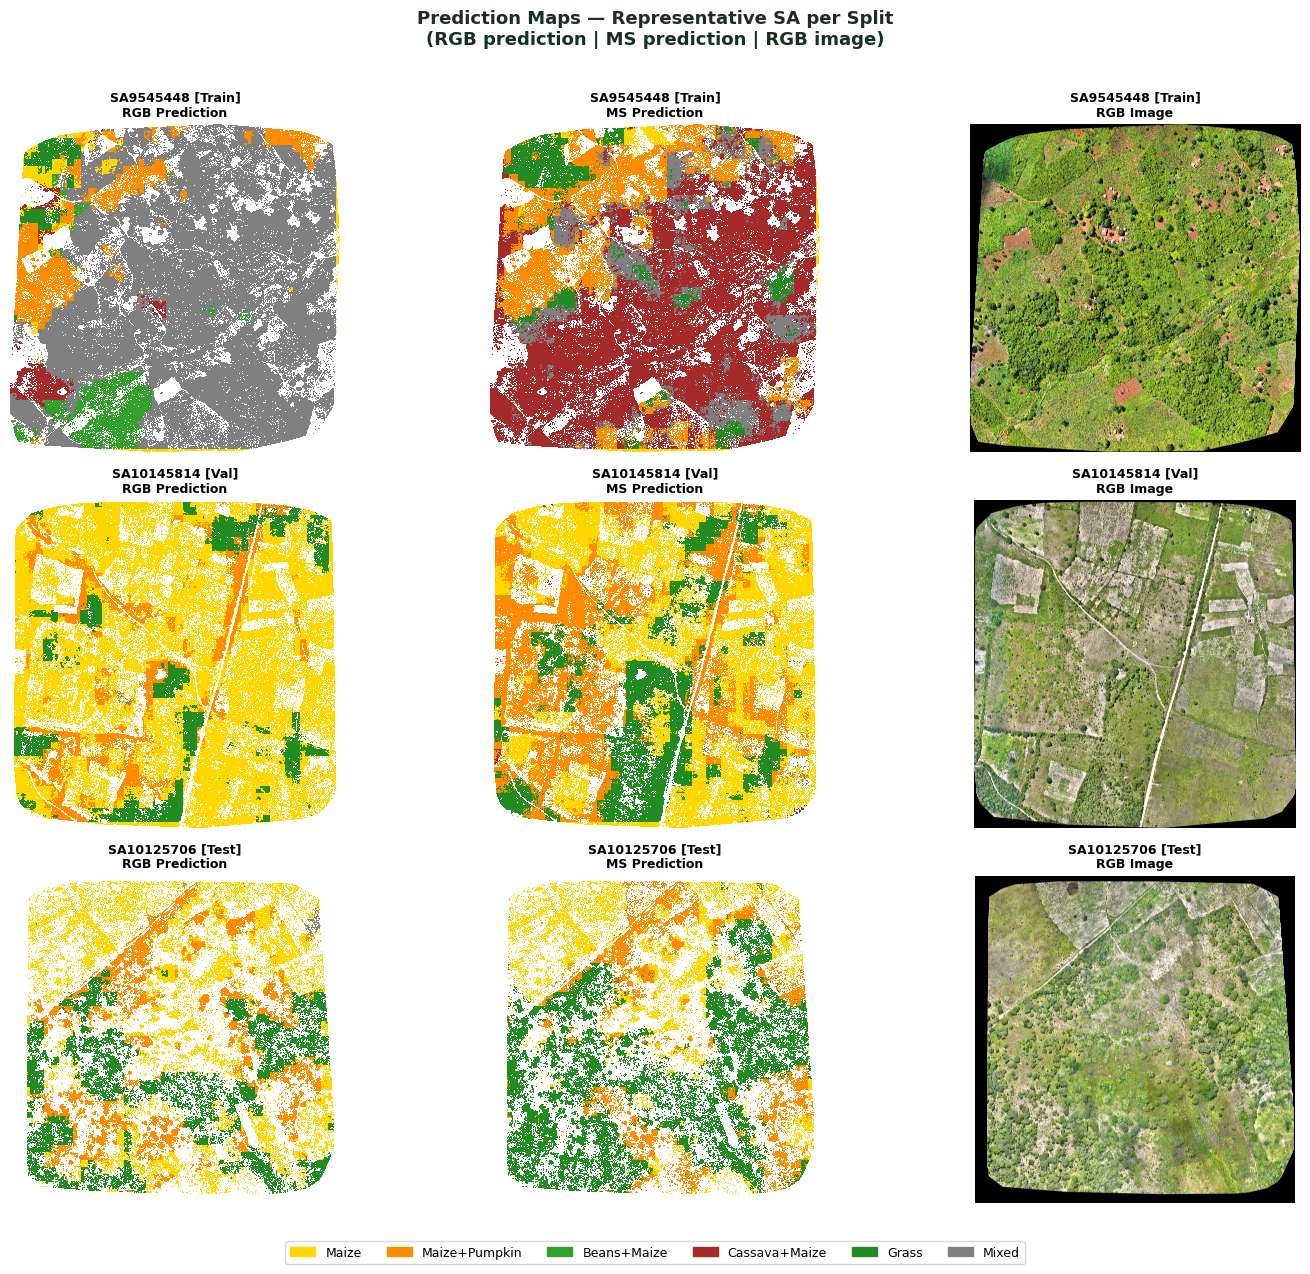

In [6]:
# ── Quick visualisation — one SA per split ───────────────────────────────
# Shows RGB image, RGB prediction, MS prediction for one SA per split

VIZ_SAS = {
    "Train": "9545448",
    "Val":   "10145814",
    "Test":  "10125706",
}

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
fig.suptitle(
    "Prediction Maps — Representative SA per Split\n"
    "(RGB prediction | MS prediction | RGB image)",
    fontsize=13, fontweight="bold", color="#1A2F23"
)

for row_idx, (split, sa_id) in enumerate(VIZ_SAS.items()):
    sa_dir   = get_sa_dir(sa_id)
    rgb_path = sa_dir / f"{sa_id}_stack_RGB.tif"

    with rasterio.open(rgb_path) as src:
        rgb_raw = src.read()[:3].transpose(1,2,0).astype(np.float32)
    p2, p98 = np.percentile(rgb_raw, 2), np.percentile(rgb_raw, 98)
    rgb_disp = np.clip((rgb_raw-p2)/(p98-p2+1e-6), 0, 1)

    pred_rgb_path = PRED_DIR/"rgb_v3"/f"{sa_id}_pred_rgb.tif"
    pred_ms_path  = PRED_DIR/"ms_v1" /f"{sa_id}_pred_ms.tif"

    with rasterio.open(pred_rgb_path) as s: pred_rgb = s.read(1)
    with rasterio.open(pred_ms_path)  as s: pred_ms  = s.read(1)

    pr = np.ma.masked_where(pred_rgb==IGNORE_INDEX, pred_rgb)
    pm = np.ma.masked_where(pred_ms ==IGNORE_INDEX, pred_ms)

    axes[row_idx,0].imshow(pr, cmap=CMAP, vmin=0, vmax=5,
                           interpolation="nearest")
    axes[row_idx,0].set_title(f"SA{sa_id} [{split}]\nRGB Prediction",
                               fontsize=9, fontweight="bold")

    axes[row_idx,1].imshow(pm, cmap=CMAP, vmin=0, vmax=5,
                           interpolation="nearest")
    axes[row_idx,1].set_title(f"SA{sa_id} [{split}]\nMS Prediction",
                               fontsize=9, fontweight="bold")

    axes[row_idx,2].imshow(rgb_disp)
    axes[row_idx,2].set_title(f"SA{sa_id} [{split}]\nRGB Image",
                               fontsize=9, fontweight="bold")

    for ax in axes[row_idx]:
        ax.axis("off")

patches = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
           for i in range(NUM_CLASSES)]
fig.legend(handles=patches, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5,0.01), fontsize=9, frameon=True)

plt.tight_layout(rect=[0,0.05,1,0.97])
save_path = BASE_DIR / "all_sa_prediction_overview.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved → {save_path}")
plt.show()